# **Exp4: Tank Efflux**

# Codes for the Graphs of the Data Received

Graph for the Variable Head of the function h(t):

slope = -0.00049581161409358
intercept = 0.6463502489047915
R^2 = 0.9998880337974347
C_d =  0.7952244222337512
-----------------------------------------------------------------------------------------------
The average velocity of the jet for the variable head is:  1.818295096360603
-----------------------------------------------------------------------------------------------

 --- Variable Head Analytical Results ---
Representative Discharge Coefficient (C_d) from Regression: 0.795
Equation of Best Fit Line: sqrt(h) = -0.00050 * t + 0.6464
-----------------------------------------------------------------------------------------------

Data Table:
 Time (s)  Height (m)  Theoretical Velocity (ms^-1)  Actual Velocity (C_d Method) (ms^-1)  Actual Velocity (Method 2) (ms^-1)  Flow Rate Q(t) (m^3*s^-1)  sqrt(h) (m^0.5)
     0.00        0.42                      2.870610                              2.282779                            2.282779                        NaN         0.648074
   

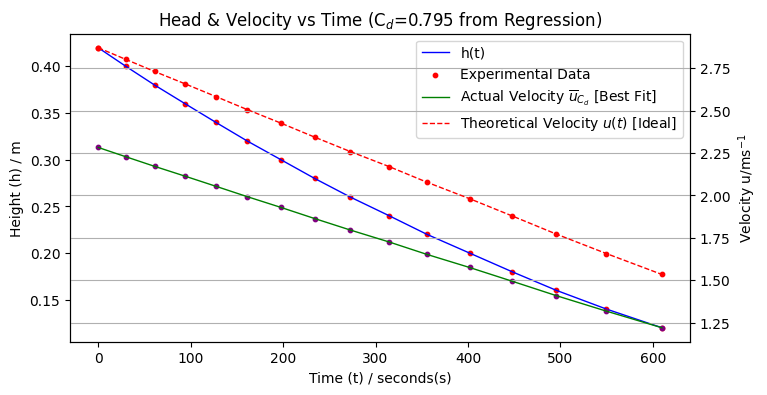

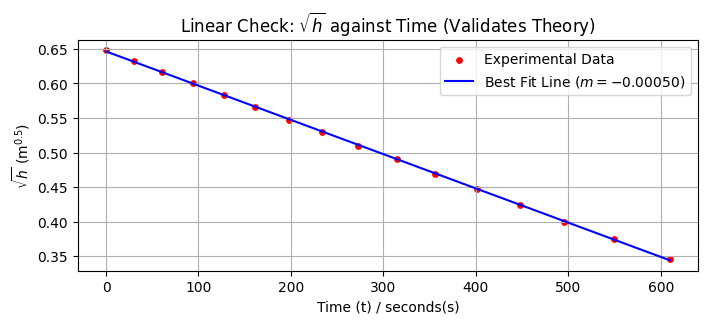

In [279]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

#Step 1: Setting up the data 
df = pd.read_csv("Data6.csv")

#Step 2: Calculating the Cd for this data frame(Why ? It will be usefull for our first data point,because we do not know the actual value of that point)
#However, we can have a good approximation by knowing the Cd coefficient,a nd just use theoretical value of the velocity derived from Bernollie Equation.
df['sqrt_h'] = np.sqrt(df['HY'])

# Drop rows where sqrt(h) cannot be computed
df_clean = df.dropna(subset=['TX', 'sqrt_h'])

reg = linregress(df_clean['TX'], df_clean['sqrt_h'])

# Regression line values
x_vals = df_clean['TX']
y_fit = reg.slope * x_vals + reg.intercept

print("slope =", reg.slope)
print("intercept =", reg.intercept)
print("R^2 =", reg.rvalue**2) #R^2 shows how close to theoretical approximation your line of best fit is. 
#As you can see it is quite close :)

#Step 3 Performing all the required algebraic calculations: 

D_orrifice = 2.5 * 10**-3
D_Tank = 149 * 10**-3

A_orrifice = (np.pi * (D_orrifice**2))/4
A_tank = (np.pi * (D_Tank**2))/4

# Calculate the representative Discharge Coefficient (C_L_exp) from the experimental slope
C_d = (-2 * A_tank / (A_orrifice * np.sqrt(2 * 9.81))) * reg.slope
print("C_d = ", C_d)

#Step 4: Replacing the first 0(NaN) value with value calculated below: 

df['u_theoretical'] = np.sqrt(2 * 9.81 * df['HY'])
df['u_actual_Cd_method'] = C_d * df['u_theoretical']

df['dh'] = df['HY'].diff()
df['dt'] = df['TX'].diff()
df['Q_actual_tank'] = A_tank * (df['dh'].abs() / df['dt'])
df['u_actual_method_2'] = df['Q_actual_tank'] / A_orrifice

#Average Velocity for the jet for the Variable Head (We take it from the method 2(with the change of V vs change of t)):
print("-----------------------------------------------------------------------------------------------")
u_average_jet = df['u_actual_method_2'].mean(skipna=True)
print("The average velocity of the jet for the variable head is: ", u_average_jet)
print("-----------------------------------------------------------------------------------------------")

#This fucntion just replaces the NaN with the value 
df.loc[0, 'u_actual_method_2'] = df.loc[0, 'u_actual_Cd_method']

#Step 5: Results and Output

print("\n --- Variable Head Analytical Results ---")
print(f"Representative Discharge Coefficient (C_d) from Regression: {C_d:.3f}")
print(f"Equation of Best Fit Line: sqrt(h) = {reg.slope:.5f} * t + {reg.intercept:.4f}")
print("-----------------------------------------------------------------------------------------------")

#Step 6: Cleaning all the data in the table: 
df = df.dropna(subset=['HY'])
df_display = df[['TX','HY','u_theoretical','u_actual_Cd_method','u_actual_method_2','Q_actual_tank','sqrt_h']].copy()
df_display.rename(columns={
    'TX' : 'Time (s)',
    'HY' : 'Height (m)',
    'sqrt_h' : 'sqrt(h) (m^0.5)',
    'u_theoretical' : 'Theoretical Velocity (ms^-1)',
    'u_actual_Cd_method' : 'Actual Velocity (C_d Method) (ms^-1)',
    'u_actual_method_2' : 'Actual Velocity (Method 2) (ms^-1)',
    'Q_actual_tank': 'Flow Rate Q(t) (m^3*s^-1)',
    'sqrt_h' : 'sqrt(h) (m^0.5)'
},inplace = True)

print("\nData Table:")
print(df_display.to_string(index=False))

print("\nData Table:")
print(df_display.to_string(index=False))

#Step 7 Plotting the Data 
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(df['TX'], df['HY'], linestyle='-', linewidth=1, color='blue', label='h(t)')
ax.scatter(df['TX'], df['HY'], marker = "o", s=10, color = 'red', label='Experimental Data')
ax.set_xlabel("Time (t) / seconds(s)")
ax.set_ylabel("Height (h) / m")

ax2 = ax.twinx()
ax2.plot(df['TX'], df['u_actual_Cd_method'], linestyle='-', linewidth=1, color='green', label='Actual Velocity $\\overline{u}_{C_d}$ [Best Fit]')
ax2.scatter(df['TX'], df['u_actual_Cd_method'], marker = "o", s=10, color = 'purple')
ax2.plot(df['TX'], df['u_theoretical'], linestyle='--', linewidth=1, color='red', label='Theoretical Velocity $u(t)$ [Ideal]')
ax2.scatter(df['TX'], df['u_theoretical'], marker = "o", s=10, color = 'red')
ax2.set_ylabel("Velocity u/ms$^{-1}$")


h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()


ax.legend(h1+h2, l1+l2, loc='upper right')

plt.title(f"Head & Velocity vs Time (C$_d$={C_d:.3f} from Regression)")

plt.grid(True)

plt.savefig("Exp_4.png", dpi=150, bbox_inches="tight")

#Step 8: The Validity of the relashinship from the Step 2
plt.figure(figsize=(8,3))
plt.scatter(df['TX'], df['sqrt_h'], linestyle='None', marker = "o", s=15, color = 'red', label='Experimental Data')
plt.plot(df['TX'], reg.slope * df['TX'] + reg.intercept, linestyle='-', color='blue', label=f'Best Fit Line ($m={reg.slope:.5f}$)')

plt.xlabel("Time (t) / seconds(s)")
plt.ylabel(r'$\sqrt{h}$ (m$^{0.5}$)')
plt.title(r'Linear Check: $\sqrt{h}$ against Time (Validates Theory)')
plt.legend()
plt.grid(True)

plt.savefig("Exp_4(Validity).png", dpi=150, bbox_inches="tight")

plt.show()
